# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"

## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

### From the plot, I observed....
Results: There is a positive correlation between `Attack` and `Defense`. The hit-points (`HP`) is higher for Pokemons with higher `Attack` and `Defense` values.

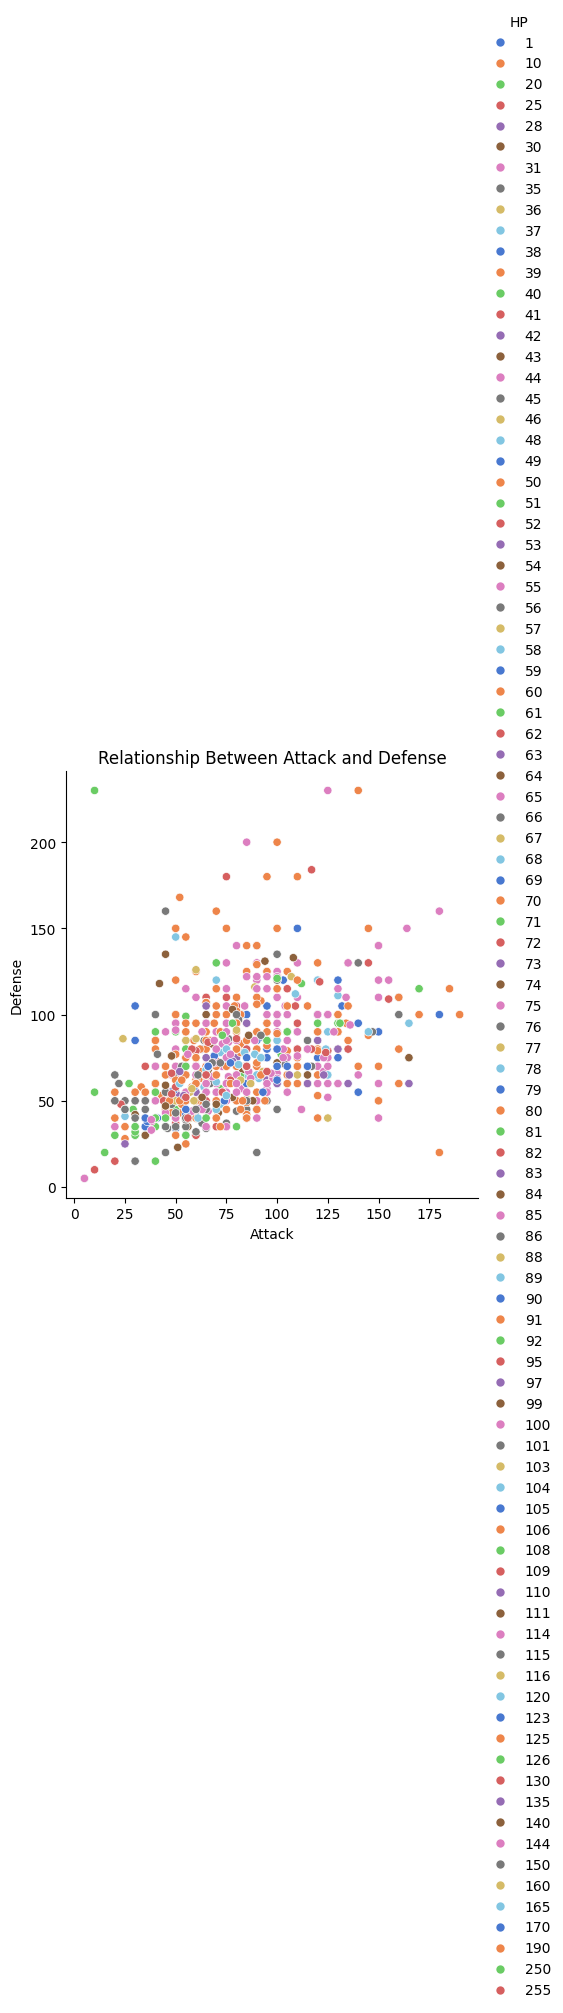

In [11]:
# Your code here . . .
# read the dataset
df = pd.read_csv(fp)
sns.relplot(
    x="Attack",
    y="Defense",
    data=df,
    hue="HP",
    palette="muted"
)
plt.title("Relationship Between Attack and Defense")
plt.show()

There is a relationship between Attack and Defense with there being a positive correlation between the two. As the attack increases, the defense tends to increase too. Most Pokemon tend to be in between 25 to a bit over 100 when it comes to both defense and attack. There is an average based on the middle cluster but there are some Pokemon that have higher defense and attack stats. 

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

Text(0.5, 0.98, 'Attack vs total for all Pokemon')

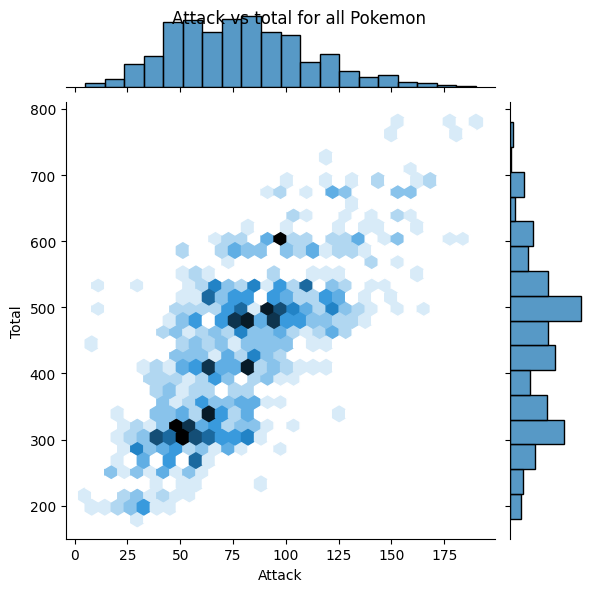

In [12]:
# Your code here . . .
Attack_Total_Graph=sns.jointplot(
    data=df, 
    x="Attack",
    y="Total",
    kind="hex",
    gridsize=30
    
)
Attack_Total_Graph.fig.suptitle("Attack vs total for all Pokemon")

From the plot, I observed....

The hexbin plot displays the relationship between Attack and Total which has a positive relationship as those with higher attack tends to have a higher total stat. Moreover, it shows shows that when it come to attacks most of the Pokemon's have an attack of around 50 to around 100 while the total value tends to be around 300 to 500 with less pokemons havine higher attacks or hight total stats as shown by the lighter colors of the hex. There is also the histograms which shows the distribution of the Attack stats showing how the distrubtion tends to be between 50 and kind of lessens after 100 while for the Total it peaks at around 500.

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

Text(0.5, 0.98, 'Counts of Pokemon Type 2')

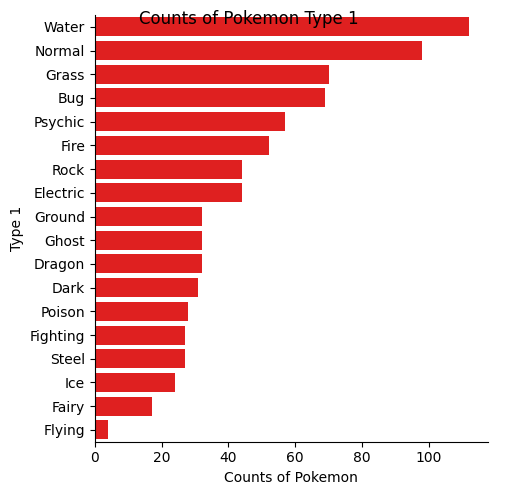

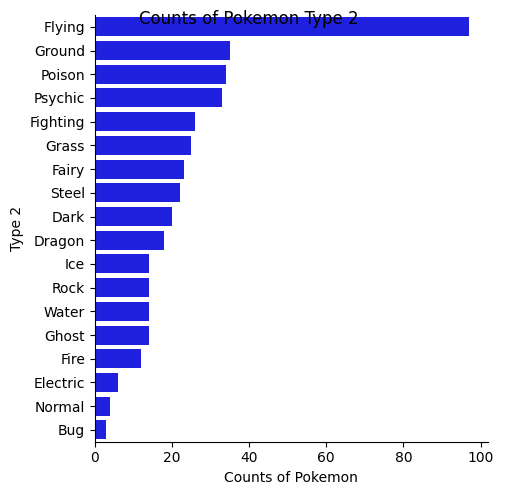

In [31]:
# Your code here . . .
# Categorical Plot 1 
Count_Type1= sns.catplot(
    y="Type 1",
    data=df,
    kind="count",
    color="red",
    order=df['Type 1'].value_counts().index,
).set_axis_labels("Counts of Pokemon", "Type 1")
Count_Type1.fig.suptitle("Counts of Pokemon Type 1")

#Categorical Plot 2 
Count_Type2 = sns.catplot(
    y="Type 2",
    data=df,
    kind="count",
    color="blue",
    order=df['Type 2'].value_counts().index,
).set_axis_labels("Counts of Pokemon", "Type 2")
Count_Type2.fig.suptitle("Counts of Pokemon Type 2")


Which are the most common Type 1 and Type 2 Pokemons, and which are the most rare ones?
1. The most common Type 1 is the Water type. The most rare type is Flying. 
2. The most common for Type 2 Pokemons is Flying and the rarest was Bug Type. 

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

Your question(s) . . .

4. How much higher are the Legendary Pokemon Stats compared to the non-Legendary Pokemon Stats?

Legendary
False    425.0
True     600.0
Name: Total, dtype: float64

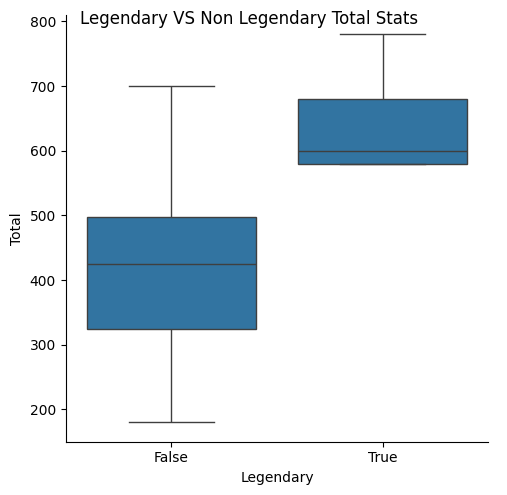

In [ ]:
# Your code here . . .
Legendary_VS_NonLegendary= sns.catplot(
  x="Legendary", 
  y="Total",
  data=df, 
  kind="box",
)
Legendary_VS_NonLegendary.fig.suptitle("Legendary VS Non Legendary Total Stats")

The Legendary Pokemons have a higher total stats compared to non Legendary Pokemons as the NonLegendary has a median of a bit over 400 around 425 but the legendary media is around 600 which means that the total stats is around 175 points higher for Legendary Pokemons. 

5. Is there a correlation between Special Attack and Special Defense for Pokemons?

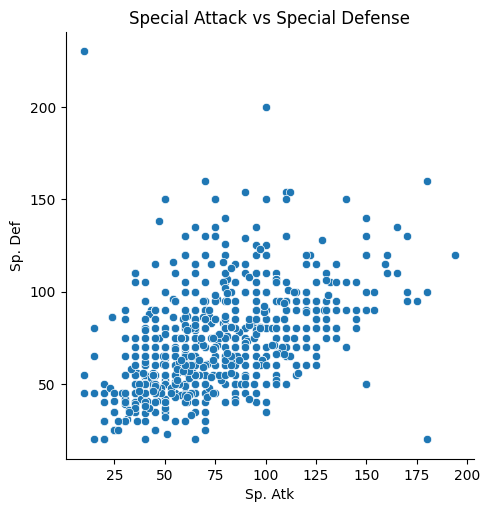

In [34]:
sns.relplot(
    data=df,
    x="Sp. Atk",
    y="Sp. Def",
    kind="scatter",
)

plt.title("Special Attack vs Special Defense")
plt.show()

 There a correlation between Special Attack and Special Defense for Pokemons as the graph shows a positive correlation between Special Attack and Special Defense as the points go upward with those with a low special attack tending to have a lower special defense meanwhile the higher the special attack, the higher special defense usually with some outliers. 

6. Are certain primary types more likely to be Legendaries?


Text(0.5, 0.98, 'Legendary Status by Type 1')

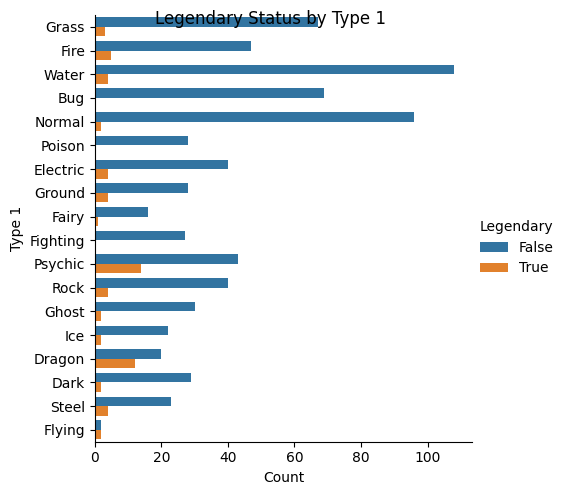

In [30]:
g= sns.catplot(
    data=df,
    y="Type 1",
    hue="Legendary",
    kind="count"
).set_axis_labels("Count", "Type 1")

g.fig.suptitle("Legendary Status by Type 1")

Yes, certain primary types  are more likely to be Legendaries as Psychic types tend to have a higher amount of legendaries compared to other types. Dragon type also has a high amount of legendaries when using the count. 